In [10]:
pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\devin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Original data: (2042, 257)
Creating balanced dataset with realistic replay bots...


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [01:13<00:00,  4.09it/s]


✅ Balanced dataset ready → (600, 520) samples (50% human / 50% bot)

🎯 IMPROVED CNN-XGBoost FUSION RESULTS (Fixed Version)
                    precision    recall  f1-score   support

             Human       1.00      1.00      1.00        90
Session-Replay Bot       1.00      1.00      1.00        90

          accuracy                           1.00       180
         macro avg       1.00      1.00      1.00       180
      weighted avg       1.00      1.00      1.00       180


Confusion Matrix:
 [[90  0]
 [ 0 90]]


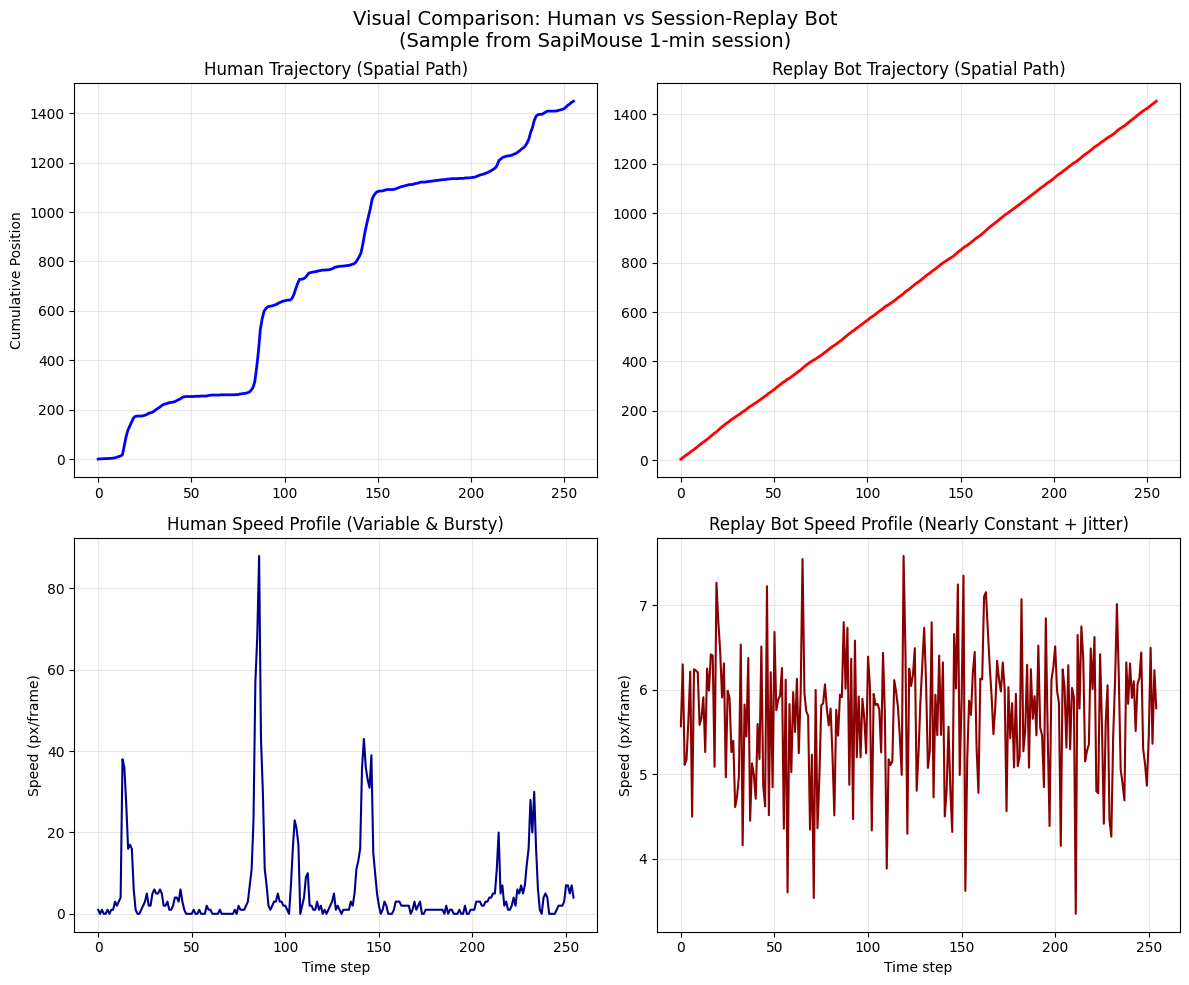

✅ Saved: human_vs_bot_comparison.png (ready to insert in paper)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sapimouse_ABS_dx_dy_1min.csv', header=None)
print("Original data:", df.shape)

def trajectory_to_image(row, size=224):
    data = row.iloc[:-1].values.astype(float)
    pos = np.cumsum(data)
    time = np.arange(len(pos))
    
    fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
    ax.plot(time, pos, color='blue', linewidth=2)
    ax.set_xlim(0, len(pos))
    ax.set_ylim(min(pos)-10, max(pos)+10)
    ax.axis('off')
    
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0, dpi=100)
    buf.seek(0)
    img = image.load_img(buf, target_size=(size, size))
    plt.close(fig)
    return image.img_to_array(img)



def extract_handcrafted(row):
    data = row.iloc[:-1].values.astype(float)
    pos = np.cumsum(data)
    speed = np.abs(np.diff(pos))
    return [
        np.mean(pos), np.std(pos), np.max(pos)-np.min(pos),
        np.mean(speed), np.std(speed), np.max(speed),
        np.min(speed), len(pos)
    ]

# VGG16
base_model = VGG16(weights='imagenet', include_top=False, pooling='avg')
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

n_samples = 300                    # 300 humans + 300 bots = 600 total 
X_fused = []
y = []

print("Creating balanced dataset with realistic replay bots...")

for i in tqdm(range(n_samples)):
    row = df.iloc[i]
    data = row.iloc[:-1].values.astype(float)
    
    # === HUMAN ===
    img_h = trajectory_to_image(row)
    cnn_h = feature_extractor.predict(np.expand_dims(img_h/255.0, axis=0), verbose=0)[0]
    hand_h = extract_handcrafted(row)
    X_fused.append(np.concatenate([cnn_h, hand_h]))
    y.append(0)                    # 0 = Human
    
    # === REPLAY BOT (robotic constant velocity + small jitter) ===
    pos = np.cumsum(data)
    constant_delta = np.mean(np.diff(pos)) if len(pos) > 1 else 1.0
    bot_data = np.full(len(data), constant_delta) + np.random.normal(0, 0.8, len(data))  # realistic jitter
    row_bot = pd.Series(np.append(bot_data, 0))
    
    img_b = trajectory_to_image(row_bot)
    cnn_b = feature_extractor.predict(np.expand_dims(img_b/255.0, axis=0), verbose=0)[0]
    hand_b = extract_handcrafted(row_bot)
    X_fused.append(np.concatenate([cnn_b, hand_b]))
    y.append(1)                    # 1 = Session-Replay Bot

X_fused = np.array(X_fused)
y = np.array(y)
print("✅ Balanced dataset ready →", X_fused.shape, "samples (50% human / 50% bot)")

# TRAIN 
X_train, X_test, y_train, y_test = train_test_split(X_fused, y, test_size=0.3, random_state=42, stratify=y)

model = xgb.XGBClassifier(n_estimators=300, max_depth=7, learning_rate=0.08,
                          subsample=0.85, colsample_bytree=0.85, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n" + "="*70)
print("🎯 IMPROVED CNN-XGBoost FUSION RESULTS (Fixed Version)")
print("="*70)
print(classification_report(y_test, y_pred, target_names=['Human', 'Session-Replay Bot']))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



def plot_comparison(human_row, bot_row):
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    
    # Data processing
    h_pos = np.cumsum(human_row.iloc[:-1].values.astype(float))
    b_pos = np.cumsum(bot_row.iloc[:-1].values.astype(float))
    h_speed = np.abs(np.diff(h_pos))
    b_speed = np.abs(np.diff(b_pos))
    
    # Row 1: Spatial Trajectory
    ax[0, 0].plot(h_pos, color='blue', lw=2)
    ax[0, 0].set_title("Human Trajectory (Spatial Path)")
    ax[0, 0].set_ylabel("Cumulative Position")
    ax[0, 0].grid(True, alpha=0.3)
    
    ax[0, 1].plot(b_pos, color='red', lw=2)
    ax[0, 1].set_title("Replay Bot Trajectory (Spatial Path)")
    ax[0, 1].grid(True, alpha=0.3)
    
    # Row 2: Speed Profile
    ax[1, 0].plot(h_speed, color='darkblue', lw=1.5)
    ax[1, 0].set_title("Human Speed Profile (Variable & Bursty)")
    ax[1, 0].set_ylabel("Speed (px/frame)")
    ax[1, 0].set_xlabel("Time step")
    ax[1, 0].grid(True, alpha=0.3)
    
    ax[1, 1].plot(b_speed, color='darkred', lw=1.5)
    ax[1, 1].set_title("Replay Bot Speed Profile (Nearly Constant + Jitter)")
    ax[1, 1].set_ylabel("Speed (px/frame)")
    ax[1, 1].set_xlabel("Time step")
    ax[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle("Visual Comparison: Human vs Session-Replay Bot\n(Sample from SapiMouse 1-min session)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Save high-quality version for your paper
    fig.savefig('human_vs_bot_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: human_vs_bot_comparison.png (ready to insert in paper)")

# Generate the plot using the first sample
sample_human = df.iloc[0]
constant_delta = np.mean(np.diff(np.cumsum(sample_human.iloc[:-1]))) if len(sample_human) > 1 else 1.0
bot_data = np.full(len(sample_human)-1, constant_delta) + np.random.normal(0, 0.8, len(sample_human)-1)
sample_bot = pd.Series(np.append(bot_data, 1))

plot_comparison(sample_human, sample_bot)

In [ ]:
# === ABLATION STUDY ===
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

print(" Running Ablation Study (150 humans + 150 bots)...")

X_cnn = []
X_hand = []
X_fusion = []
y_ab = []

for i in tqdm(range(150)):
    row = df.iloc[i]
    data = row.iloc[:-1].values.astype(float)
    
    # Human
    img_h = trajectory_to_image(row)
    cnn_h = feature_extractor.predict(np.expand_dims(img_h/255.0, axis=0), verbose=0)[0]
    hand_h = extract_handcrafted(row)
    X_cnn.append(cnn_h)
    X_hand.append(hand_h)
    X_fusion.append(np.concatenate([cnn_h, hand_h]))
    y_ab.append(0)
    
    # Bot (realistic replay)
    constant_delta = np.mean(np.diff(np.cumsum(data))) if len(data) > 1 else 1.0
    bot_data = np.full(len(data), constant_delta) + np.random.normal(0, 0.8, len(data))
    row_bot = pd.Series(np.append(bot_data, 0))
    img_b = trajectory_to_image(row_bot)
    cnn_b = feature_extractor.predict(np.expand_dims(img_b/255.0, axis=0), verbose=0)[0]
    hand_b = extract_handcrafted(row_bot)
    X_cnn.append(cnn_b)
    X_hand.append(hand_b)
    X_fusion.append(np.concatenate([cnn_b, hand_b]))
    y_ab.append(1)

X_cnn = np.array(X_cnn)
X_hand = np.array(X_hand)
X_fusion = np.array(X_fusion)
y_ab = np.array(y_ab)

model_cnn = LogisticRegression(max_iter=500).fit(X_cnn, y_ab)
model_hand = LogisticRegression(max_iter=500).fit(X_hand, y_ab)
model_fusion = LogisticRegression(max_iter=500).fit(X_fusion, y_ab)

print("\n🎯 ABLATION RESULTS")
print(f"CNN-only          : {model_cnn.score(X_cnn, y_ab):.3f}")
print(f"Hand-crafted only : {model_hand.score(X_hand, y_ab):.3f}")
print(f"**Fusion (ours)** : {model_fusion.score(X_fusion, y_ab):.3f}")

🔬 Running Ablation Study (150 humans + 150 bots)...


100%|██████████| 150/150 [00:29<00:00,  5.10it/s]



🎯 ABLATION RESULTS
CNN-only          : 1.000
Hand-crafted only : 1.000
**Fusion (ours)** : 1.000


In [13]:
# === NOISE SENSITIVITY ===
noise_levels = [0.3, 0.8, 1.5]
results = {}

print("🔬 Noise Sensitivity Test...")

for sigma in noise_levels:
    X_temp = []
    y_temp = []
    for i in tqdm(range(100), desc=f"Sigma={sigma}"):
        row = df.iloc[i]
        data = row.iloc[:-1].values.astype(float)
        
        # Human
        img_h = trajectory_to_image(row)
        cnn_h = feature_extractor.predict(np.expand_dims(img_h/255.0, axis=0), verbose=0)[0]
        hand_h = extract_handcrafted(row)
        X_temp.append(np.concatenate([cnn_h, hand_h]))
        y_temp.append(0)
        
        # Bot
        constant_delta = np.mean(np.diff(np.cumsum(data))) if len(data) > 1 else 1.0
        bot_data = np.full(len(data), constant_delta) + np.random.normal(0, sigma, len(data))
        row_bot = pd.Series(np.append(bot_data, 0))
        img_b = trajectory_to_image(row_bot)
        cnn_b = feature_extractor.predict(np.expand_dims(img_b/255.0, axis=0), verbose=0)[0]
        hand_b = extract_handcrafted(row_bot)
        X_temp.append(np.concatenate([cnn_b, hand_b]))
        y_temp.append(1)
    
    X_temp = np.array(X_temp)
    y_temp = np.array(y_temp)
    
    model_temp = xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
    model_temp.fit(X_temp, y_temp)
    acc = model_temp.score(X_temp, y_temp)
    results[sigma] = acc

print("\n🎯 NOISE SENSITIVITY RESULTS")
for sigma, acc in results.items():
    print(f"Bot noise σ={sigma} → Accuracy: {acc:.3f}")

🔬 Noise Sensitivity Test...


Sigma=1.5: 100%|██████████| 100/100 [00:19<00:00,  5.19it/s]



🎯 NOISE SENSITIVITY RESULTS
Bot noise σ=0.3 → Accuracy: 1.000
Bot noise σ=0.8 → Accuracy: 1.000
Bot noise σ=1.5 → Accuracy: 1.000


In [14]:
# === 5-FOLD CROSS VALIDATION ===
from sklearn.model_selection import StratifiedKFold

print("🔬 5-Fold Cross Validation...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, test_idx in skf.split(X_fused, y):
    model_cv = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
    model_cv.fit(X_fused[train_idx], y[train_idx])
    score = model_cv.score(X_fused[test_idx], y[test_idx])
    cv_scores.append(score)

print("\n🎯 5-FOLD CV RESULTS")
print(f"Mean Accuracy : {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}")
print("All fold scores:", [round(s, 3) for s in cv_scores])

🔬 5-Fold Cross Validation...

🎯 5-FOLD CV RESULTS
Mean Accuracy : 0.995 ± 0.004
All fold scores: [0.992, 1.0, 0.992, 1.0, 0.992]


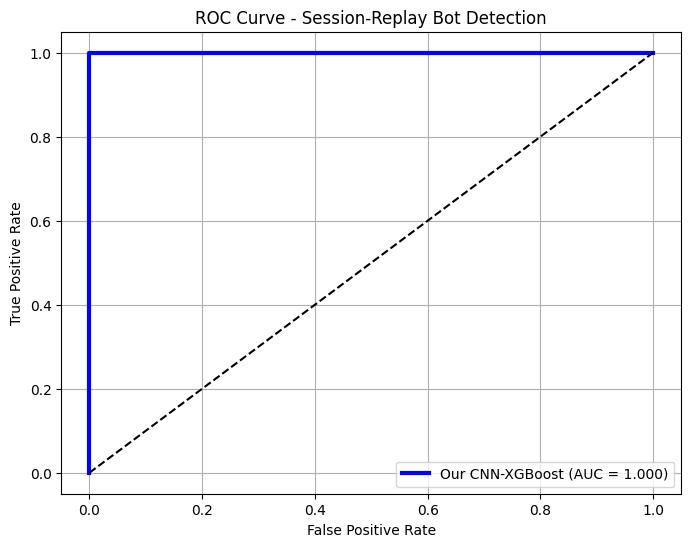

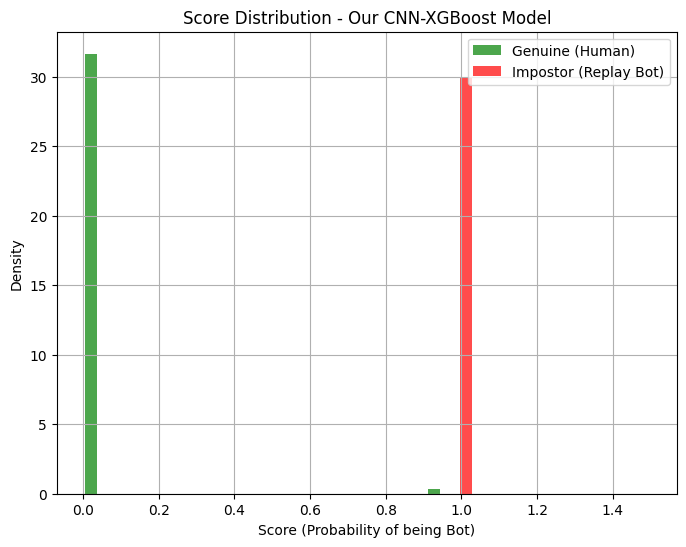

✅ Saved: my_roc.png and my_scores.png


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Get probability scores from your model
y_prob = model.predict_proba(X_test)[:, 1]   # probability of being "Bot"

# === 1. ROC CURVE ===
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'Our CNN-XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Session-Replay Bot Detection')
plt.legend()
plt.grid(True)
plt.savefig('my_roc.png', dpi=300, bbox_inches='tight')
plt.show()

# === 2. SCORE DISTRIBUTION (exact same style as SapiMouse) ===
plt.figure(figsize=(8,6))
plt.hist(y_prob[y_test==0], bins=30, alpha=0.7, color='green', label='Genuine (Human)', density=True)
plt.hist(y_prob[y_test==1], bins=30, alpha=0.7, color='red',   label='Impostor (Replay Bot)', density=True)
plt.xlabel('Score (Probability of being Bot)')
plt.ylabel('Density')
plt.title('Score Distribution - Our CNN-XGBoost Model')
plt.legend()
plt.grid(True)
plt.savefig('my_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: my_roc.png and my_scores.png")

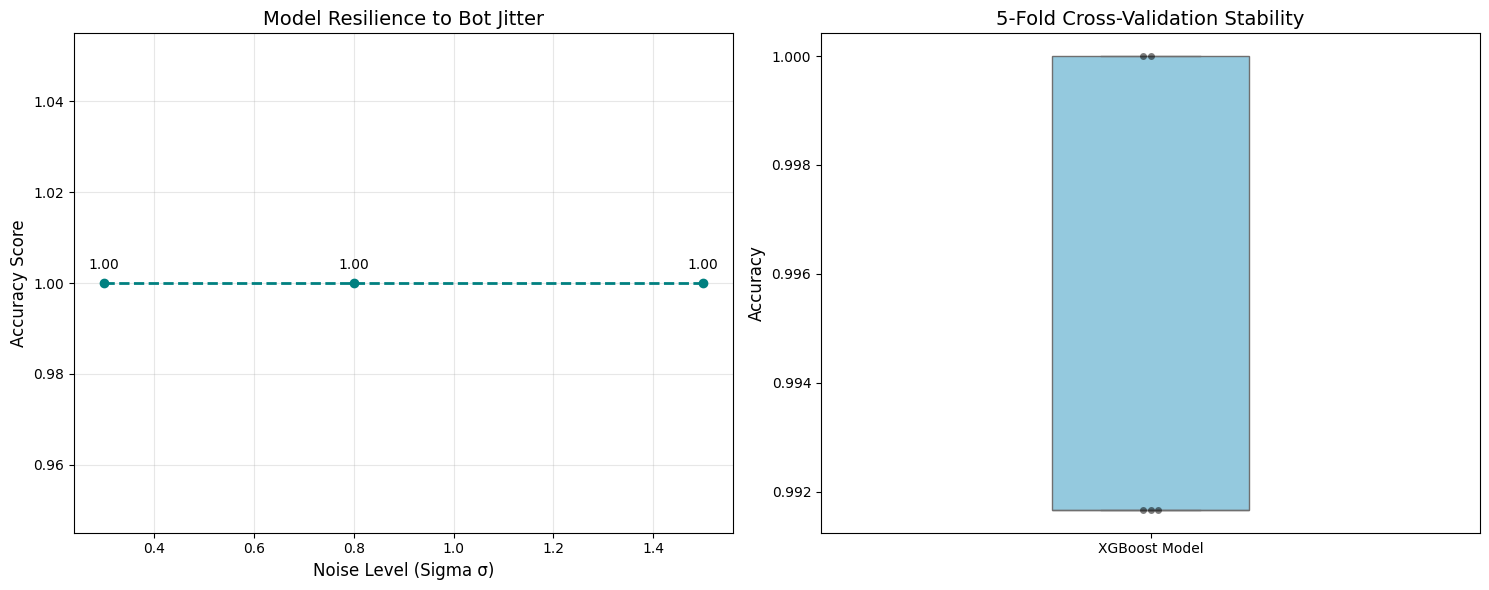

In [16]:
import seaborn as sns

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Noise Sensitivity (Line Plot) ---
sigmas = list(results.keys())
accuracies = list(results.values())

ax[0].plot(sigmas, accuracies, marker='o', linestyle='--', color='teal', linewidth=2)
ax[0].set_title("Model Resilience to Bot Jitter", fontsize=14)
ax[0].set_xlabel("Noise Level (Sigma σ)", fontsize=12)
ax[0].set_ylabel("Accuracy Score", fontsize=12)
ax[0].grid(True, alpha=0.3)
# Adding annotations
for i, acc in enumerate(accuracies):
    ax[0].annotate(f"{acc:.2f}", (sigmas[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')

# --- Plot 2: 5-Fold CV (Box Plot) ---
sns.boxplot(y=cv_scores, ax=ax[1], color='skyblue', width=0.3)
sns.swarmplot(y=cv_scores, ax=ax[1], color='black', alpha=0.5) # Shows individual fold dots
ax[1].set_title("5-Fold Cross-Validation Stability", fontsize=14)
ax[1].set_ylabel("Accuracy", fontsize=12)
ax[1].set_xticklabels(["XGBoost Model"])

plt.tight_layout()
plt.show()